# AD implementation CPM 

This notebook tests automatic differentiation ptychography (ADP) based on JAX and Optax for a simple Fraunhofer propagator. This compares directly with the mPIE implementation and should reach similar level of accuracy.

In [1]:
# all required modules imported
import numpy as np
from PtyLabX.utils.utils import circ, gaussian2D, cart2pol
from PtyLabX.utils.scanGrids import GenerateNonUniformFermat
from PtyLabX.Operators.Operators import aspw
from PtyLabX.utils.visualisation import hsvplot, absplot, show3Dslider
import matplotlib.pylab as plt
from scipy.signal import convolve2d
from PtyLabX.utils.gpuUtils import check_backend

check_backend()

INFO:2026-02-24 17:42:43,437:jax._src.xla_bridge:834: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


('gpu', [CudaDevice(id=0)])

In the next step we define the geometry of the experiment and calculate the grids in the sample and detector plane. The geometry of the experiment for a standard conventional ptychography experiment is defined by three parameter:

1. The wavelength of the illuminating beam, which we assume here to be 632.8 nm
2. The distance between the sample and the detector (which we name zo)
3. The shape (Nd) and pixelsize (dxd) of the detector

In [2]:
# Set the geometry of the Experiment
wavelength = 632.8e-9
zo = 5e-2
Nd = 2**7
dxd = 16 * 4.5e-6

# Calculate the length of the detector
Ld = Nd * dxd

# probe coordinates
dxp = wavelength * zo / Ld
Np = Nd
Lp = dxp * Np
xp = np.arange(-Np // 2, Np // 2) * dxp
Xp, Yp = np.meshgrid(xp, xp)

# object coordinates
No = 2**9
dxo = dxp
Lo = dxo * No
xo = np.arange(-No // 2, No // 2) * dxo
Xo, Yo = np.meshgrid(xo, xo)

## 2. Definition of the illuminating beam
In the next step we define the beam (probe), which we want to use for our simulation. Here, a pinhole is simulated which is convolved with a gaussian kernel.

In [3]:
# generate illumination
# note: simulate focused beam
# goal: 1:1 image iris through (low-NA) lens with focal length f onto an object
f = 5e-3  # focal length of lens, creating a focused probe
pinhole = circ(Xp, Yp, Lp / 2)
pinhole = convolve2d(pinhole, gaussian2D(5, 1).astype(np.float32), mode="same")

Next, we propagate probe on the sample using a propagator and use the matplotlib to plot the probe.

Text(0.5, 1.0, 'probe intensity')

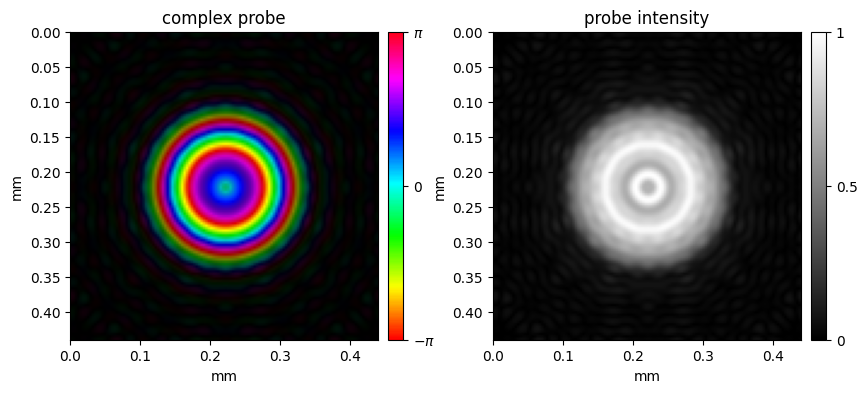

In [4]:
# propagate to lens
probe = aspw(pinhole, 2 * f, wavelength, Lp, is_FT=False)[0]

# multiply with quadratic phase and aperture
aperture = circ(Xp, Yp, 3 * Lp / 4)
aperture = convolve2d(aperture, gaussian2D(5, 3).astype(np.float32), mode="same")
probe = probe * np.exp(-1.0j * 2 * np.pi / wavelength * (Xp**2 + Yp**2) / (2 * f)) * aperture
probe = aspw(probe, 2 * f, wavelength, Lp, is_FT=False)[0]

plt.figure(figsize=(10, 4), num=1)
ax1 = plt.subplot(121)
hsvplot(probe, ax=ax1, pixelSize=dxp, axisUnit="mm")
ax1.set_title("complex probe")
ax2 = plt.subplot(122)
absplot(abs(probe), ax=ax2, pixelSize=dxp, axisUnit="mm", cmap="gray")
ax2.set_title("probe intensity")
# plt.show(block=False)

## 3. Definition of an object
In this example we define a binary spiral as a test object. The object needs to have a larger array size than the probe, since the probe is scanned over the object.

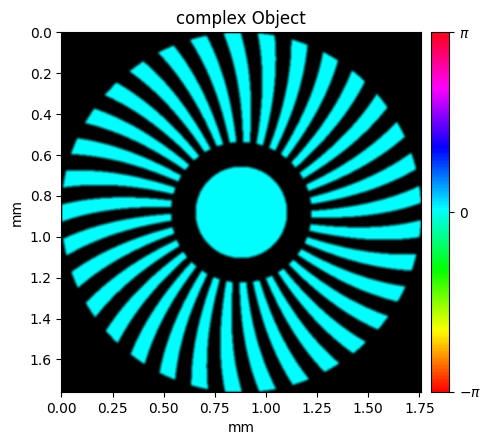

In [5]:
# generate object
d = 1e-3  # the smaller this parameter the larger the spatial frequencies in the simulated object
b = 33  # topological charge (feel free to play with this number)
theta, rho = cart2pol(Xo, Yo)
t = (1 + np.sign(np.sin(b * theta + 2 * np.pi * (rho / d) ** 2))) / 2
t = t * circ(Xo, Yo, Lo) * (1 - circ(Xo, Yo, 200 * dxo)) + circ(Xo, Yo, 130 * dxo)
obj = convolve2d(t, gaussian2D(5, 3), mode="same")  # smooth edges

plt.figure(figsize=(5, 5))
ax = plt.axes()
hsvplot(np.squeeze(obj), ax=ax, axisUnit="mm", pixelSize=dxo)
ax.set_title("complex Object")
plt.show(block=False)

## 4. Definition of the scan map
In the next step we create a scan grid with 100 points. For this purpose, we use a ptyLab internal function that generates a grid in which the scan points are distributed as homogeneously as possible (Fermat's spiral).

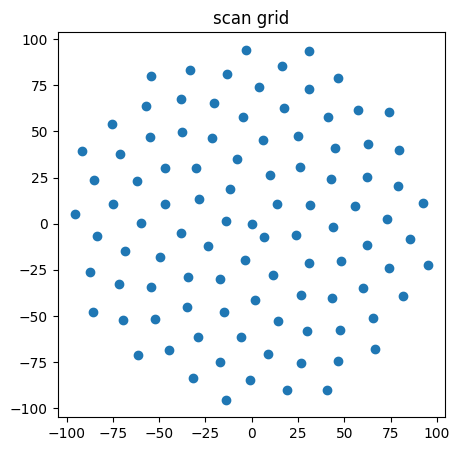

In [11]:
numPoints = 100  # number of points
radius = 100  # radius of final scan grid (in pixels)
p = 1  # p = 1 is standard Fermat;  p > 1 yields more points towards the center of grid
y_coord, x_coord = GenerateNonUniformFermat(numPoints, radius=radius, power=p)

# show scan grid
plt.figure(figsize=(5, 5))
plt.plot(y_coord, x_coord, "o")
plt.title("scan grid")
plt.show(block=False)

In the next step we calculate the physical coordinates (in meters) and save them together in a single array, which we call encoder. The scan positions are plotted for illustration on the simulated object.

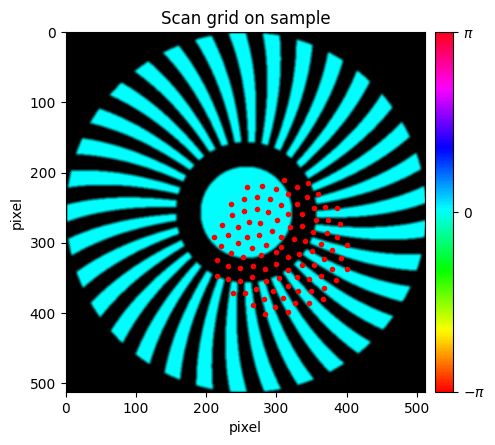

In [12]:
# Calculate
encoder = np.vstack((y_coord * dxo, x_coord * dxo)).T

# prevent negative indices by centering spiral coordinates on object
positions = np.round(encoder / dxo)
offset = 50
positions = (positions + No // 2 - Np // 2 + offset).astype(int)

# get number of positions
numFrames = len(x_coord)

# show scan grid on object
plt.figure(figsize=(5, 5))
ax1 = plt.axes()
hsvplot(np.squeeze(obj), ax=ax1)
ax1.plot(positions[:, 1] + Np // 2, positions[:, 0] + Np // 2, ".", c="red")
ax1.set_title("Scan grid on sample")
plt.show(block=False)

## 5. Calculate diffraction data
Finally we have all the information to calculate the diffraction patterns. For this purpose we create a 3-dimensionale array, which is used to store for each position the diffraction data. We name this array ptychogram. 

In [8]:
# generate the ptychogram array
ptychogram = np.zeros((numFrames, Nd, Nd))

In the next step, we iterate through all the calculated positions and slice the object according to the size of the probe-array. The slice is named object patch. Since the object patch has the same size as the sample, the exit-surface-wave (esw) can be calculated in the next step. The esw represents the electric field directly behind the sample. Thus, the electric field in the detector plane can be calculated by the Fourier transform of the esw (far-field approximation).

In [13]:
# --- loop through every scan position ---
for loop in np.arange(numFrames):
    # get object patch
    row, col = positions[loop]
    sy = slice(row, row + Np)
    sx = slice(col, col + Np)
    # note that object patch has size of probe array
    objectPatch = obj[..., sy, sx].copy()
    # multiply each probe mode with object patch
    esw = objectPatch * probe
    # generate diffraction data, propagate the esw to the detector plane
    ESW = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(esw), norm="ortho"))
    # save data in ptychogram
    ptychogram[loop] = abs(ESW) ** 2

## 6. AD-based Reconstruction

Now we set up the AD-based gradient-descent reconstruction for flexibility of modeling and estimation of any parameter as required. The key idea: define a **pure forward model** function
`(object_patch, probe) -> I_estimated`, wrap it in a loss function, and let `jax.value_and_grad` compute
gradients automatically. An Optax optimizer (Adam) handles the updates.

The forward model is identical to the simulation above:
`esw = object_patch * probe` → `ESW = FFT(esw)` → `I = |ESW|²`

This is a Fraunhofer (far-field) propagator — the simplest case.

In [14]:
import jax
import jax.numpy as jnp
import optax
from PtyLabX.utils.utils import fft2c, ifft2c


# --- Forward model (pure function, no side effects) ---
@jax.jit
def forward_model(object_patch, probe):
    """Forward model: object * probe ->  propagate -> intensity."""
    esw = object_patch * probe
    ESW = fft2c(esw)
    I_est = jnp.abs(ESW) ** 2
    return I_est


# --- Loss functions ---
@jax.jit
def amplitude_loss(object_patch, probe, I_meas):
    """Gaussian/amplitude loss: ||sqrt(I_meas) - sqrt(I_est)||^2"""
    I_est = forward_model(object_patch, probe)
    return jnp.mean((jnp.sqrt(I_meas + 1e-10) - jnp.sqrt(I_est + 1e-10)) ** 2)


@jax.jit
def poisson_loss(object_patch, probe, I_meas):
    """For photon-limited imaging, Poisson negative
    log-likelihood loss: sum(I_est - I_meas * log(I_est))"""
    I_est = forward_model(object_patch, probe)
    return jnp.mean(I_est - I_meas * jnp.log(I_est + 1e-10))


@jax.jit
def anscombe_loss(object_patch, probe, I_meas):
    """Anscombe variance-stabilizing transform loss
    for Poisson noise: sum()
    """
    I_est = forward_model(object_patch, probe)
    return jnp.mean(2 * jnp.sqrt(I_meas + 3 / 8) - 2 * jnp.sqrt(I_est + 3 / 8))


# Choose which loss to use
loss_fn = amplitude_loss

In [ ]:
a = jnp.array([1.0, 2.0, 3.0])
a = np.array([1.0, 2.0, 3.0]) + 1j * np.array([1.0, 2.0, 3.0])
jnp.asarray(a).dtype

dtype('complex128')

### Initialize reconstruction state

Start from a uniform object guess (all ones) and a circular probe guess.
The true probe could also be used; here we test blind recovery of both.

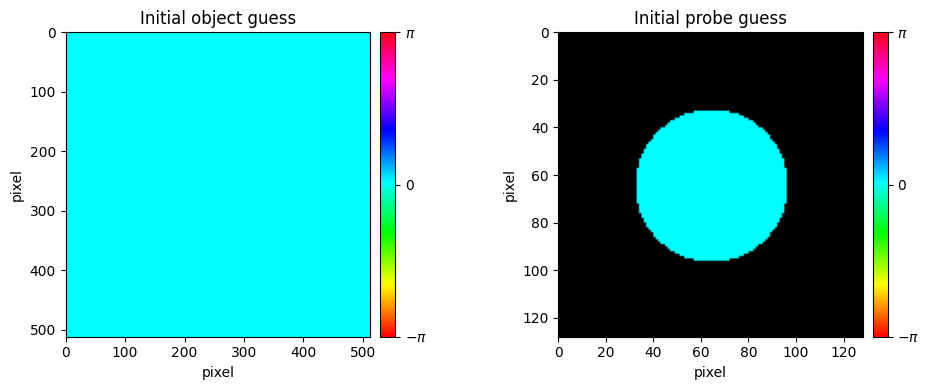

In [17]:
# Convert measured data to JAX arrays
ptychogram_jax = jnp.array(ptychogram)

# Object: start from uniform (all ones, complex)
obj_rec = jnp.ones((No, No), dtype=jnp.complex64)

# Probe: start from a simple circular aperture guess (not the true probe)
probe_rec = jnp.array(circ(Xp, Yp, Lp / 2), dtype=jnp.complex64)

# Convert positions to JAX
positions_jax = jnp.array(positions)

plt.figure(figsize=(10, 4))
ax1 = plt.subplot(121)
hsvplot(np.asarray(obj_rec), ax=ax1)
ax1.set_title("Initial object guess")
ax2 = plt.subplot(122)
hsvplot(np.asarray(probe_rec), ax=ax2)
ax2.set_title("Initial probe guess")
plt.tight_layout()

### Reconstruction loop

The core AD reconstruction. For each position:
1. Extract object patch at that scan position
2. Compute `loss, (grad_obj, grad_probe) = value_and_grad(loss_fn)(patch, probe, I_meas)`
3. Apply optimizer update to both object patch and probe
4. Write updated patch back into the full object array

This uses `jax.value_and_grad` with `argnums=(0, 1)` to differentiate w.r.t. both object patch and probe simultaneously.

In [ ]:
# --- Optimizer setup ---
# Separate optimizers for object and probe (different learning rates)
obj_optimizer = optax.adam(learning_rate=1e-2)
probe_optimizer = optax.adam(learning_rate=1e-2)

obj_opt_state = obj_optimizer.init(obj_rec)
probe_opt_state = probe_optimizer.init(probe_rec)

# Gradient function: differentiates loss w.r.t. object_patch (arg 0) and probe (arg 1)
grad_fn = jax.jit(jax.value_and_grad(loss_fn, argnums=(0, 1)))

# --- Reconstruction parameters ---
num_iterations = 50
error_history = []

# --- Reconstruction loop ---
for iteration in range(num_iterations):
    # Shuffle position order each iteration (stochastic)
    rng_key = jax.random.PRNGKey(iteration)
    position_order = jax.random.permutation(rng_key, numFrames)

    iteration_loss = 0.0

    for idx in range(numFrames):
        pos_idx = int(position_order[idx])
        row, col = int(positions[pos_idx, 0]), int(positions[pos_idx, 1])
        sy = slice(row, row + Np)
        sx = slice(col, col + Np)

        # Extract object patch
        object_patch = obj_rec[sy, sx]

        # Get measured intensity for this position
        I_meas = ptychogram_jax[pos_idx]

        # Compute loss and gradients via AD
        loss_val, (grad_obj_patch, grad_probe) = grad_fn(object_patch, probe_rec, I_meas)
        iteration_loss += float(loss_val)

        # Apply optimizer updates to object patch
        obj_updates, obj_opt_state = obj_optimizer.update(grad_obj_patch, obj_opt_state, object_patch)
        new_patch = optax.apply_updates(object_patch, obj_updates)

        # Apply optimizer updates to probe
        probe_updates, probe_opt_state = probe_optimizer.update(grad_probe, probe_opt_state, probe_rec)
        probe_rec = optax.apply_updates(probe_rec, probe_updates)

        # Write updated patch back into full object (immutable JAX update)
        obj_rec = obj_rec.at[sy, sx].set(new_patch)

    # Track error
    mean_loss = iteration_loss / numFrames
    error_history.append(mean_loss)

    if iteration % 10 == 0 or iteration == num_iterations - 1:
        print(f"Iteration {iteration:3d}/{num_iterations}: loss = {mean_loss:.6f}")

### Results

In [ ]:
# --- Plot results ---
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Reconstructed object
ax = axes[0, 0]
hsvplot(np.asarray(obj_rec), ax=ax)
ax.set_title("Reconstructed object (complex)")

# Ground truth object
ax = axes[0, 1]
hsvplot(np.squeeze(obj), ax=ax)
ax.set_title("Ground truth object")

# Reconstructed probe
ax = axes[1, 0]
hsvplot(np.asarray(probe_rec), ax=ax)
ax.set_title("Reconstructed probe (complex)")

# Ground truth probe
ax = axes[1, 1]
hsvplot(probe, ax=ax)
ax.set_title("Ground truth probe")

# Error curve
ax = axes[0, 2]
ax.semilogy(error_history)
ax.set_xlabel("Iteration")
ax.set_ylabel("Mean loss")
ax.set_title("Convergence")
ax.grid(True)

# Reconstructed vs ground truth probe intensity
ax = axes[1, 2]
ax.plot(np.asarray(jnp.abs(probe_rec[Np // 2, :])), label="Reconstructed")
ax.plot(np.abs(probe[Np // 2, :]), "--", label="Ground truth")
ax.set_title("Probe intensity (center line)")
ax.legend()

plt.tight_layout()
plt.show()

### Experiments to try

Things to play with in this notebook:
- **Switch loss function**: Change `loss_fn = amplitude_loss` to `loss_fn = poisson_loss` and compare convergence
- **Learning rates**: Try `1e-1`, `1e-3` — Adam is fairly robust but the ratio between object and probe LR matters
- **Optimizer**: Replace `optax.adam` with `optax.sgd(learning_rate, momentum=0.9)` to compare
- **Staged optimization**: Only update object for the first 10 iterations (freeze probe), then enable both
- **Number of iterations**: 50 is conservative; the loss curve will tell you when to stop